Images found: 1 ['world_frames_images/cell6_output0.png']
Origin:  [[384.21054   78.965904]]


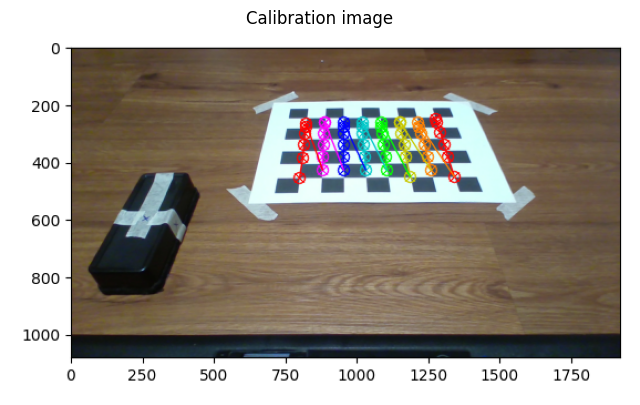

Camera matrix : 

[[2.26050904e+03 0.00000000e+00 3.05637893e+02]
 [0.00000000e+00 1.48559983e+03 1.64200034e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
dist : 

[[ 2.36088144e+01  1.93069917e+02  2.33444447e+00  1.66720724e-01
  -2.43941142e+04]]
rvecs : 

(array([[-0.74696762],
       [-0.75757698],
       [ 1.383846  ]]),)
tvecs : 

(array([[ 2.50175667],
       [-6.99710686],
       [60.81113325]]),)


In [ ]:
#!/usr/bin/env python

#Intrinsic and extrinsic camera calibration 

#reference: https://learnopencv.com/camera-calibration-using-opencv/
#reference: https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html

import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
 
# Defining the dimensions of checkerboard
CHECKERBOARD = (6,8)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
 
# Creating vector to store vectors of 3D points for each checkerboard image
objpoints = []
# Creating vector to store vectors of 2D points for each checkerboard image
imgpoints = []
 
# Defining the world coordinates for 3D points
objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[0,:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
prev_img_shape = None

# Extracting path of individual image stored in a given directory
# Fix (absolute path)
### MODIFIED
# Reason: original absolute folder was not available here, so use the extracted image
# from the notebook outputs while keeping the same image-list workflow.
images = ['world_frames_images/cell6_output0.png']
print('Images found:', len(images), images)
### END MODIFIED

for fname in images:
    img = cv2.imread(fname)
    ### MODIFIED
    # Reason: give a clear error if the image path is wrong instead of failing later.
    if img is None:
        raise FileNotFoundError(f'Could not read image: {fname}')
    ### END MODIFIED
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    # Find the chess board corners
    # If desired number of corners are found in the image then ret = true
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)
 
    """
    If desired number of corner are detected,
    we refine the pixel coordinates and display
    them on the images of checker board
    """

    if ret == True:
        objpoints.append(objp)
        # refining pixel coordinates for given 2d points.
        corners2 = cv2.cornerSubPix(gray, corners, (11,11),(-1,-1), criteria)
         
        imgpoints.append(corners2)

        #Code for finding the origin:
        print("Origin: ", corners2[0])
 
        # Draw and display the corners
        img = cv2.drawChessboardCorners(img, CHECKERBOARD, corners2, ret)
     
    ### MODIFIED
    # Reason: cv2.imshow does not work reliably in notebooks/headless environments.
    plt.figure(figsize=(8, 5))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Calibration image')
    plt.axis('off')
    plt.show()
    ### END MODIFIED
 
### MODIFIED
# Reason: no GUI windows are opened in the notebook version.
# cv2.destroyAllWindows()
### END MODIFIED
 
### MODIFIED
# Reason: fail clearly if no corners were detected before calibration.
if len(objpoints) == 0 or len(imgpoints) == 0:
    raise RuntimeError('No checkerboard corners were detected; cannot calibrate.')
### END MODIFIED
h,w = img.shape[:2]
 
"""
Performing camera calibration by
passing the value of known 3D points (objpoints)
and corresponding pixel coordinates of the
detected corners (imgpoints)
"""
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
 
print("Camera matrix : \n")
print(mtx)
print("dist : \n")
print(dist)
print("rvecs : \n")
print(rvecs)
print("tvecs : \n")
print(tvecs)

#Camera matrix, distortion coefficients, rotational vector, translational vector

Images found: 1 ['world_frames_images/cell6_output0.png']


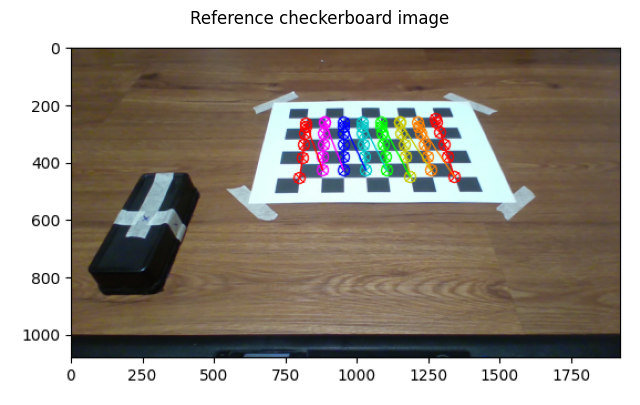

Camera matrix : 

[[2.26050904e+03 0.00000000e+00 3.05637893e+02]
 [0.00000000e+00 1.48559983e+03 1.64200034e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
dist : 

[[ 2.36088144e+01  1.93069917e+02  2.33444447e+00  1.66720724e-01
  -2.43941142e+04]]
rotation vector : 

(array([[-0.74696762],
       [-0.75757698],
       [ 1.383846  ]]),)
translation vector : 

(array([[ 2.50175667],
       [-6.99710686],
       [60.81113325]]),)


In [2]:
#Picture taken to use as a reference:

#!/usr/bin/env python

#Intrinsic and extrinsic camera calibration 

#reference: https://learnopencv.com/camera-calibration-using-opencv/
#reference: https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html

import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
 
# Defining the dimensions of checkerboard
CHECKERBOARD = (6,8)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
 
# Creating vector to store vectors of 3D points for each checkerboard image
objpoints = []
# Creating vector to store vectors of 2D points for each checkerboard image
imgpoints = []
 
 
# Defining the world coordinates for 3D points
objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[0,:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
prev_img_shape = None

# Extracting path of individual image stored in a given directory
# Fix (absolute path)
### MODIFIED
# Reason: original absolute folder was not available here, so use the extracted image
# from the notebook outputs while keeping the same image-list workflow.
images = ['world_frames_images/cell6_output0.png']
print('Images found:', len(images), images)
### END MODIFIED

for fname in images:
    img = cv2.imread(fname)
    ### MODIFIED
    # Reason: give a clear error if the image path is wrong instead of failing later.
    if img is None:
        raise FileNotFoundError(f'Could not read image: {fname}')
    ### END MODIFIED
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    # Find the chess board corners
    # If desired number of corners are found in the image then ret = true
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)
     
    """
    If desired number of corner are detected,
    we refine the pixel coordinates and display
    them on the images of checker board
    """

    if ret == True:
        objpoints.append(objp)
        # refining pixel coordinates for given 2d points.
        corners2 = cv2.cornerSubPix(gray, corners, (11,11),(-1,-1), criteria)
         
        imgpoints.append(corners2)
 
        # Draw and display the corners
        img = cv2.drawChessboardCorners(img, CHECKERBOARD, corners2, ret)
     
    ### MODIFIED
    # Reason: cv2.imshow does not work reliably in notebooks/headless environments.
    plt.figure(figsize=(8, 5))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Reference checkerboard image')
    plt.axis('off')
    plt.show()
    ### END MODIFIED
 
### MODIFIED
# Reason: no GUI windows are opened in the notebook version.
# cv2.destroyAllWindows()
### END MODIFIED
 
### MODIFIED
# Reason: fail clearly if no corners were detected before calibration.
if len(objpoints) == 0 or len(imgpoints) == 0:
    raise RuntimeError('No checkerboard corners were detected; cannot calibrate.')
### END MODIFIED
h,w = img.shape[:2]
 
"""
Performing camera calibration by
passing the value of known 3D points (objpoints)
and corresponding pixel coordinates of the
detected corners (imgpoints)
"""
ret, mtx, dist, rotation_vector, translation_vector = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
 
print("Camera matrix : \n")
print(mtx)
print("dist : \n")
print(dist)
print("rotation vector : \n")
print(rotation_vector)
print("translation vector : \n")
print(translation_vector)

#Camera matrix, distortion coefficients, rotational vector, translational vector

In [3]:
#Using pixels and coordinate frame position
#Need to make sure we are using the right values for conversion
#Reference: https://stackoverflow.com/questions/63882698/how-to-estimate-intrinsic-properties-of-a-camera-from-data

#Coordinate transformations between pixel coordinate frame and image coordinate frame

# x_value of P with respect to image coordinate frame
r_coordinate = 1600
# y_value of P with respect to image coordinate frame
c_coordinate = 690

# x_value of P with respect to pixel coordinate frame
cx_point = 322.63054805
# y_value of P with respect to pixel coordinate frame
cy_point = 239.50400572

# width of the pixel with a unit in meters
fx_point = 582.58989853
# height of the pixel with a unit in meters
fy_point = 583.49673112

# x_value of the principal point with respect to the pixel coordinate frame
z_dist = 42.5 #Distance from camera to the object
# y_value of the principal point with respect to the pixel coordinate frame

# s_x, s_y, o_r, o_c: Intrinsic parameters of the camera

x = (cx_point - r_coordinate) * (z_dist / fx_point)
print("x", x)
y = (cy_point - c_coordinate) * (z_dist / fy_point)
print("y", y)

x -93.18424820762571
y -32.81265984155527


In [ ]:
#Converting to the world frame
 
#Rotation vector is in a 3x1 vector form. The inverse of it needs to be taken, but to take an inverse you need a square matrix (3x3)
#Rotation vector represnets the axis and angle of rotation and the rotation matrix represents the full 3D transformation that can be applied in a 3D space
#So need to convert using the Rodrigues formula (axis-angle vector(3x1) to a rotation matrix(3x3))
#Reference: https://medium.com/@sim30217/rotation-vector-vs-rotation-matrices-2b7ab7287b47
 
R, _ = cv2.Rodrigues(rotation_vector[0])
t = translation_vector[0]
 
#convert camera frame into 3x1 column vector so it can be used in the matrix math
camera_frame = np.array([[x],
                         [y],
                         [z_dist]])
 
R_inv = np.linalg.inv(R)
 
world_frame = R_inv @ (camera_frame - t)
 
print("Object position in world frame (Xw, Yw, Zw):", world_frame)

Object position in world frame (Xw, Yw, Zw): [[-30.24971765]
 [ 67.7351783 ]
 [ 68.22354512]]


Images found: 1 ['world_frames_images/cell6_output0.png']


Camera matrix : 

[[2.26052651e+03 0.00000000e+00 3.05637995e+02]
 [0.00000000e+00 1.48561031e+03 1.64200131e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
dist : 

[[ 2.36089931e+01  1.93082027e+02  2.33445691e+00  1.66721090e-01
  -2.43951892e+04]]
rvecs : 

(array([[-0.7469686 ],
       [-0.7575775 ],
       [ 1.38384587]]),)
tvecs : 

(array([[  5.50384964],
       [-15.39363957],
       [133.78524871]]),)
objpoints: 
[[ 0.   0.   0. ]
 [ 2.2  0.   0. ]
 [ 4.4  0.   0. ]
 [ 6.6  0.   0. ]
 [ 8.8  0.   0. ]
 [11.   0.   0. ]
 [ 0.   2.2  0. ]
 [ 2.2  2.2  0. ]
 [ 4.4  2.2  0. ]
 [ 6.6  2.2  0. ]
 [ 8.8  2.2  0. ]
 [11.   2.2  0. ]
 [ 0.   4.4  0. ]
 [ 2.2  4.4  0. ]
 [ 4.4  4.4  0. ]
 [ 6.6  4.4  0. ]
 [ 8.8  4.4  0. ]
 [11.   4.4  0. ]
 [ 0.   6.6  0. ]
 [ 2.2  6.6  0. ]
 [ 4.4  6.6  0. ]
 [ 6.6  6.6  0. ]
 [ 8.8  6.6  0. ]
 [11.   6.6  0. ]
 [ 0.   8.8  0. ]
 [ 2.2  8.8  0. ]
 [ 4.4  8.8  0. ]
 [ 6.6  8.8  0. ]
 [ 8.8  8.8  0. ]
 [11.   8.8  0. ]
 [ 0.  11.   0. ]
 [ 2.2 11

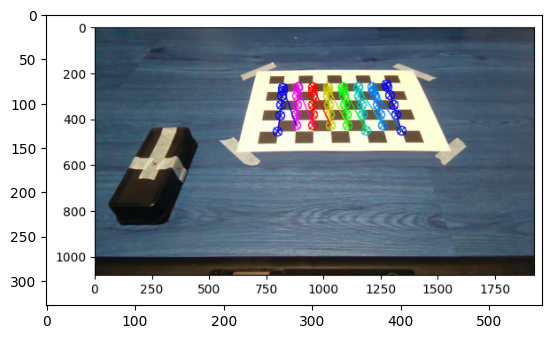

In [5]:
#Intrinsic Calculator

#reference: https://learnopencv.com/camera-calibration-using-opencv/
 
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
 
# Defining the dimensions of checkerboard
CHECKERBOARD = (6,8)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
 
# Creating vector to store vectors of 3D points for each checkerboard image
objpoints = []
# Creating vector to store vectors of 2D points for each checkerboard image
imgpoints = []
 
# Defining the world coordinates for 3D points
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)*2.2
prev_img_shape = None
 
# Extracting path of individual image stored in a given directory
# Fix (absolute path)
### MODIFIED
# Reason: original absolute folder was not available here, so use the extracted image
# from the notebook outputs while keeping the same image-list workflow.
images = ['world_frames_images/cell6_output0.png']
print('Images found:', len(images), images)
### END MODIFIED
counter = 0
for fname in images:
    img = cv2.imread(fname)
    ### MODIFIED
    # Reason: give a clear error if the image path is wrong instead of failing later.
    if img is None:
        raise FileNotFoundError(f'Could not read image: {fname}')
    ### END MODIFIED
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    # Find the chess board corners
    # If desired number of corners are found in the image then ret = true
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)
     
    """
    If desired number of corner are detected,
    we refine the pixel coordinates and display
    them on the images of checker board
    """
    if ret == True:
        objpoints.append(objp)
        # refining pixel coordinates for given 2d points.
        corners2 = cv2.cornerSubPix(gray, corners, (11,11),(-1,-1), criteria)
         
        imgpoints.append(corners2)
 
        # Draw and display the corners
        img = cv2.drawChessboardCorners(img, CHECKERBOARD, corners2, ret)
     
    #cv2.imshow('img',img)
    #cv2.waitKey(0)
    
    
    if(counter%10 == 0 ):
        fig, ax = plt.subplots()
        ax.imshow(img)
    counter+=1
### MODIFIED
# Reason: no GUI windows are opened in the notebook version.
# cv2.destroyAllWindows()
### END MODIFIED
 
### MODIFIED
# Reason: fail clearly if no corners were detected before calibration.
if len(objpoints) == 0 or len(imgpoints) == 0:
    raise RuntimeError('No checkerboard corners were detected; cannot calibrate.')
### END MODIFIED
h,w = img.shape[:2]

"""
Performing camera calibration by
passing the value of known 3D points (objpoints)
and corresponding pixel coordinates of the
detected corners (imgpoints)
"""
ret, k_mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
 
print("Camera matrix : \n")
print(k_mtx)
print("dist : \n")
print(dist)
print("rvecs : \n")
print(rvecs)
print("tvecs : \n")
print(tvecs)
print("objpoints: ")
print(objpoints[0])#shows a total of 48 points



In [6]:
 
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


k_mtx = np.array([
    [582.58988818,   0.        , 322.630546  ],
    [  0.        , 583.49670491, 239.50400497],
    [  0.        ,   0.        ,   1.        ]
])

dist = np.array([[-6.80826578e-02,  9.41783583e-01, -1.85169649e-03, -6.77107409e-04, -2.80139113e+00]])

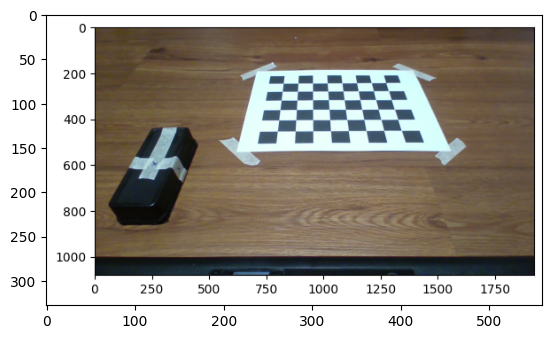

In [7]:
#Intrinsic Calculator

#reference: https://learnopencv.com/camera-calibration-using-opencv/
 
# Defining the dimensions of checkerboard
CHECKERBOARD = (6,8)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
 
# Creating vector to store vectors of 3D points for each checkerboard image
objpoints = []
# Creating vector to store vectors of 2D points for each checkerboard image
imgpoints = []

square_size = 2.2
 
# Defining the world coordinates for 3D points
objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[0,:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)*square_size
prev_img_shape = None
 
# Extracting path of individual image stored in a given directory
# Fix (absolute path)

### MODIFIED
# Reason: test_frame_1 1.jpg was not included, so use the extracted image from
# the notebook output while keeping the same variable names.
checkerboard_image_path = 'world_frames_images/cell6_output0.png'
img = mpimg.imread(checkerboard_image_path)
### END MODIFIED
fig, ax = plt.subplots()
ax.imshow(img)
#Notice how we can use cv2 or mpimg for printing the image? It may not look like it
#but it matters for the cell after this because it expects a certain arrangement of the data
#which it is wanting the cv2 arrangements
### MODIFIED
# Reason: read the same extracted image using OpenCV for the next cell.
img = cv2.imread(checkerboard_image_path)
if img is None:
    raise FileNotFoundError(f'Could not read image: {checkerboard_image_path}')
### END MODIFIED


Chessboard corners found: True
Counter:  1
ret was equal to True
Origin pixel location (col, row): [384.21054   78.965904]
Camera matrix : 

[[582.58988818   0.         322.630546  ]
 [  0.         583.49670491 239.50400497]
 [  0.           0.           1.        ]]
dist : 

[[-6.80826578e-02  9.41783583e-01 -1.85169649e-03 -6.77107409e-04
  -2.80139113e+00]]
rvecs : 

[[-0.66484185]
 [ 0.6071556 ]
 [ 1.43901457]]
tvecs : 

[[  8.11538729]
 [-20.91361039]
 [ 75.3398847 ]]
Origin coordinates: 
 [384.21054   78.965904]
Camera position in world coordinates (-R.T @ t):
 [[ 68.81762453]
 [ 12.01739528]
 [-36.04238618]]


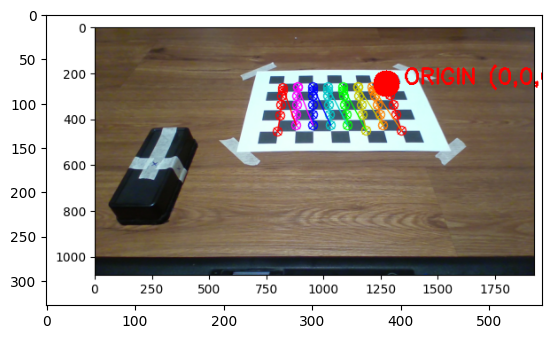

In [8]:
import matplotlib.pyplot as plt

gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
# Find the chess board corners
# If desired number of corners are found in the image then ret = true
ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)
### MODIFIED
# Reason: print the actual detection result and stop clearly if detection fails.
print("Chessboard corners found:", ret)
if not ret:
    raise RuntimeError('Checkerboard corners were not found. Check CHECKERBOARD size and image quality.')
### END MODIFIED
"""
If desired number of corner are detected,
we refine the pixel coordinates and display
them on the images of checker board
"""
counter=0
if ret == True:
    objpoints.append(objp)
    # refining pixel coordinates for given 2d points.
    corners2 = cv2.cornerSubPix(gray, corners, (11,11),(-1,-1), criteria)
    
    imgpoints.append(corners2)

    # Draw and display the corners
    img = cv2.drawChessboardCorners(img, CHECKERBOARD, corners2, ret)
    counter+=1
    print("Counter: ", counter)
print("ret was equal to True")

origin_pixel_coords = corners2[0][0]
print("Origin pixel location (col, row):", origin_pixel_coords)

img_origin = img.copy()
cv2.circle(img_origin, 
           (int(origin_pixel_coords[0]), int(origin_pixel_coords[1])), 
           radius=15, 
           color=(0, 0, 255),
           thickness=-1)
cv2.putText(img_origin, "ORIGIN (0,0,0)", 
            (int(origin_pixel_coords[0]) + 20, int(origin_pixel_coords[1])),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

checkered_image = img_origin
fig, ax = plt.subplots()
#Shows the origin explicitly in the graph
ax.imshow(cv2.cvtColor(checkered_image, cv2.COLOR_BGR2RGB))

# cv2.imshow('img',img)
# cv2.waitKey(0)
 
### MODIFIED
# Reason: no GUI windows are opened in the notebook version.
# cv2.destroyAllWindows()
### END MODIFIED
 
h,w = img.shape[:2]

"""
Performing camera calibration by
passing the value of known 3D points (objpoints)
and corresponding pixel coordinates of the
detected corners (imgpoints)
"""
# ret, k_mtx, dist, world_frame_rvecs, world_frame_tvecs = cv2.calibrateCamera(
#     objpoints, 
#     imgpoints, 
#     gray.shape[::-1], 
#     None, 
#     None
# )
ret, world_frame_rvecs, world_frame_tvecs = cv2.solvePnP(
    objpoints[0].reshape(-1, 3),   # <-- fix shape from (1,48,3) to (48,3)
    imgpoints[0].reshape(-1, 1, 2), # <-- ensure correct shape
    k_mtx,
    dist
)
world_frame_tvecs = world_frame_tvecs
print("Camera matrix : \n")
print(k_mtx)
print("dist : \n")
print(dist)
print("rvecs : \n")
print(world_frame_rvecs)
print("tvecs : \n")
#tvecs is such a large number, but when looking at the picture I see that in the x it 
#goes over 24.6 cm and down 4.4 cm meaning that perhaps we were in mm instead of cm
print(world_frame_tvecs)
print("Origin coordinates: \n", origin_pixel_coords)

### MODIFIED
# Reason: show that -R.T @ t is the camera position in the world frame,
# not the world frame itself.
world_frame_R, _ = cv2.Rodrigues(world_frame_rvecs)
camera_position_world = -world_frame_R.T @ world_frame_tvecs
print("Camera position in world coordinates (-R.T @ t):\n", camera_position_world)
### END MODIFIED

#We now have the camera matrix, distortion coeff, t vecotr, R vector



Saved simulated live click: u= 105 , v= 200


(np.float64(-0.5), np.float64(559.5), np.float64(327.5), np.float64(-0.5))

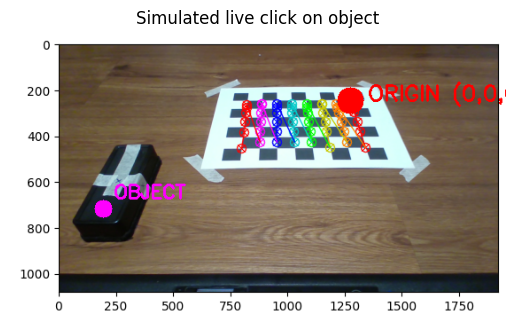

In [9]:
#Gets u,v - the pixel coordinates of the object

#Reference: https://techvidvan.com/tutorials/displaying-the-coordinates-of-points-clicked-on-the-image-using-python-opencv/

#Loads image in a window and you can click on it to get the coordinate directly instead of using MS Paint

### MODIFIED
# Reason: cv2.imshow mouse callbacks do not run reliably inside notebooks/headless environments.
# Keep the same u_coordinate/v_coordinate variables, but simulate one live click on the object.
u_coordinate = 105
v_coordinate = 200
print("Saved simulated live click: u=", u_coordinate, ", v=", v_coordinate)

object_click_image = checkered_image.copy()
cv2.circle(object_click_image, (u_coordinate, v_coordinate), 10, (255, 0, 255), -1)
cv2.putText(object_click_image, "OBJECT", (u_coordinate + 12, v_coordinate - 12),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 255), 2)
fig, ax = plt.subplots()
ax.imshow(cv2.cvtColor(object_click_image, cv2.COLOR_BGR2RGB))
ax.set_title("Simulated live click on object")
ax.axis("off")
### END MODIFIED


x using guessed camera depth: -13.074495909627924
y using guessed camera depth: -2.3695766613853673
Object position in camera using guessed depth: (np.float64(-13.074495909627924), np.float64(-2.3695766613853673), 35)
Object location on table: X = 24.29 cm, Y = 30.23 cm
Object location if clicked point is on top: X = 20.58 cm, Y = 31.75 cm, height = 3.00 cm


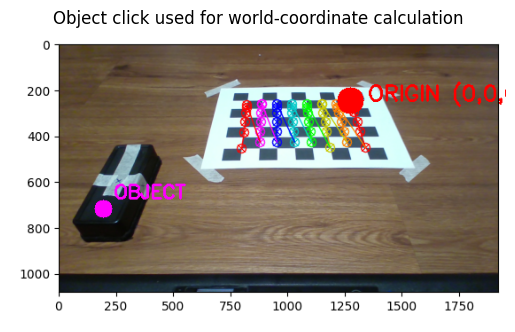

In [10]:
#Getting the camera frame

# Getting the intrinsic values from the calibration 

#focal length in x direction
fx = k_mtx[0, 0]
#Focal length in y direction
fy = k_mtx[1, 1]
#Image center x coordinate
cx = k_mtx[0, 2]
#Image center y coordinate
cy = k_mtx[1, 2]

#Pixel coordinates from cell above
u_point = u_coordinate
v_point = v_coordinate

#Distance from camera to the object
z_dist = 35
#X distance from camera
x_cam = (u_point - cx) * (z_dist / fx)
print("x using guessed camera depth:", x_cam)
#Y distance from camera
y_cam = (v_point - cy) * (z_dist / fy)
print("y using guessed camera depth:", y_cam)

#Store camera frame for objects positions (xc, yc, zc)
object_position_camera = (x_cam, y_cam, z_dist)
print("Object position in camera using guessed depth:", object_position_camera)

fig, ax = plt.subplots()
ax.imshow(cv2.cvtColor(object_click_image, cv2.COLOR_BGR2RGB))
ax.set_title("Object click used for world-coordinate calculation")
ax.axis("off")

#Getting the world frame 
'''
World frame - apply r and t to camera frame coordinates, find objects world frame coords 
    with ruler, compute error between measured and calculated

Calculate [xw, yw, zw] with respect to the world frame using these equations
    [xc yc zc]' = Rcw[xw yw zw]' + dcw
    [xw yw zw]' = Rcw^-1*([xc yc zc]'- dcw) 
'''

### MODIFIED
# Reason: The object is on the same flat table/checkerboard plane. Because the board is
# skewed, the depth to the origin is not the same as depth to the object. Use R and t
# to intersect the clicked pixel ray with the world/table plane instead of guessing depth.

def pixel_to_world_plane(u, v, plane_z):
    pixel = np.array([[[u, v]]], dtype=np.float64)
    normalized = cv2.undistortPoints(pixel, k_mtx, dist)[0, 0]
    ray_camera = np.array([[normalized[0]], [normalized[1]], [1.0]], dtype=np.float64)

    world_frame_R, _ = cv2.Rodrigues(world_frame_rvecs)
    camera_position_world = -world_frame_R.T @ world_frame_tvecs
    ray_world = world_frame_R.T @ ray_camera

    scale = (plane_z - camera_position_world[2, 0]) / ray_world[2, 0]
    return camera_position_world + scale * ray_world

# If the clicked point is where the object touches the table, use Z=0.
table_z = 0.0
obj_wld_coords = pixel_to_world_plane(u_point, v_point, table_z)
print(f"Object location on table: X = {obj_wld_coords[0, 0]:.2f} cm, Y = {obj_wld_coords[1, 0]:.2f} cm")

# If the clicked point is on the top of a thick object, provide the object height.
object_height = 3.0
obj_wld_coords_top = pixel_to_world_plane(u_point, v_point, table_z + object_height)
print(f"Object location if clicked point is on top: X = {obj_wld_coords_top[0, 0]:.2f} cm, Y = {obj_wld_coords_top[1, 0]:.2f} cm, height = {object_height:.2f} cm")
### END MODIFIED


In [ ]:
'''
My attempt at a pseudo code
If there is a '*' that means idk what it does 

Libaries 

Define Checkerboard dimensions
*Create a criteria function 

objpoints - stores 3D points for checkerboard as vector
imgpoints - stores 2D points for checkerboard as vector
*So does that mean objpoints is the coord in the camera frame 
*while imgpoints is the 

*Create objp zero matrix 
*Defining the world coordinates for 3D points

Grab image

for loop for all images 
    put img into matrix
    turn into gray scale
    find corners on checkerboard and return bool and corner
    *IDK what is in the corners matrix
    if ret == true
        *add new objp to the objpoints vector
        #if objp and objpoints are both defined outside of the for loop, 
        #   why is ret the reason we add it?

        *get corners2
        add new corners2 to image points

h,w from img.shape col 3

Used calibrate camera to get ret, mtx, dist, rvecs, tvecs
#I should use solve PNP instead, right?

*Get r and c coordinates from img vector
Find cx and cy with math equations
Find fx and fy from k_mtx and math

Plug in manual z axis for camera frame to object

Find x and y of the object from the camera frame
Add z value and have full coordinate

Use rvec and rodrigues to find R 3x3 matrix

Use math to find object position in world frame with tvec, inv_R
'''